<a href="https://colab.research.google.com/github/pranita2113/EE_machine_learning/blob/main/Task6_EE514.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report
)

In [9]:
data = pd.read_csv("/content/wireless_signal_dataset.csv", sep=',', skipinitialspace=True)

In [7]:
print("Dataset Preview:")
print(data.head())
print("\nDataset Columns:")
print(data.columns)

Dataset Preview:
  RSSI,RSRP,RSRQ,SNR,Latency,Packet_Loss
0                     -45,-75,-5,30,10,1
1                     -48,-78,-6,28,12,1
2                     -50,-80,-7,27,15,2
3                     -52,-82,-8,25,18,2
4                     -55,-85,-9,23,20,3

Dataset Columns:
Index(['RSSI,RSRP,RSRQ,SNR,Latency,Packet_Loss'], dtype='object')


In [10]:
import pandas as pd
# Fix incorrect parsing where all columns are merged into one string column
if len(data.columns) == 1 and ',' in data.columns[0]:
    col_names = data.columns[0].split(',')
    data = data.iloc[:, 0].str.split(',', expand=True)
    data.columns = col_names

# Convert columns back to numeric values
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Since 'Delivery_Success' does not exist in the dataset, we will dynamically create
# our target variable 'Signal_Quality' using the 'RSSI' column which is present.
print("Available Columns in Data:", list(data.columns))
print("\nCreating Signal Quality using RSSI...")
data["Signal_Quality"] = data["RSSI"].apply(
    lambda x: "Good" if x > -70 else "Poor"
)
y = data["Signal_Quality"]

Available Columns in Data: ['RSSI', 'RSRP', 'RSRQ', 'SNR', 'Latency', 'Packet_Loss']

Creating Signal Quality using RSSI...


In [14]:
# 1. Separate features and target
X = data.drop(columns=['Signal_Quality'])
y = data['Signal_Quality']

# 2. Encode the target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# 4. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 6. Evaluate model
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         6
        Poor       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Confusion Matrix:
[[6 0]
 [0 3]]


In [11]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nTarget Classes:")
print(encoder.classes_)


Target Classes:
['Good' 'Poor']


In [12]:
# Use the columns that actually exist in your dataset as features
X = data[
[
"RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]

In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
# Fixing the typo from '_train' to 'X_train'
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)
# Training
model.fit(
    X_train,
    y_train
)

SVC(C=1)

In [18]:
y_pred = model.predict(
    X_test
)

In [19]:
print("\nAccuracy:")
print(
    round(
        accuracy_score(
            y_test,
            y_pred
        )*100,
        2
    ),
    "%"
)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)



Accuracy:
100.0 %

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         4
        Poor       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



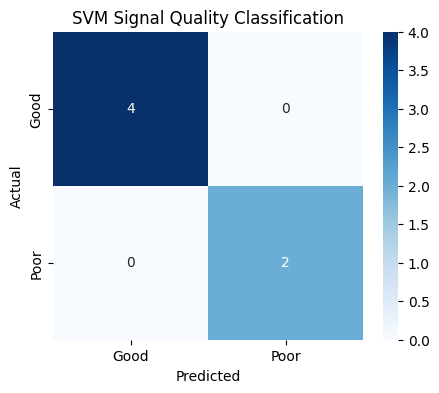

In [20]:
cm = confusion_matrix(
y_test,
y_pred
)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
xticklabels=encoder.classes_,
yticklabels=encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Signal Quality Classification")
plt.show()

In [23]:
# Update the feature array shape for predictions to match the 6 features
new_signal = [[-65, -95, -12, 15, 40, 8]]
# Features are: RSSI, RSRP, RSRQ, SNR, Latency, Packet_Loss

new_signal = scaler.transform(new_signal)
prediction = model.predict(new_signal)

print("\nNew Signal Quality:")
print(prediction[0])


New Signal Quality:
Good


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
